In [1]:
# Data manipulation libraries
import numpy as np
import pandas as pd

# Data Visulaization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

#To ensure that plots are displayed inline in jupyter notebook
%matplotlib inline

In [2]:
# Menghubungkan Google Colab dengan Google Drive
from google.colab import drive

# Mount Google Drive ke Colab
drive.mount('/content/drive')

# Setelah ini, kamu bisa mengakses file di Google Drive melalui path '/content/drive/My Drive/'

Mounted at /content/drive


In [3]:
# Memuat dataset dari Google Drive
import pandas as pd

# Path ke file dataset di Google Drive
file_path = '/content/drive/MyDrive/Pembelajaran Mesin/data.csv'

# Memuat dataset ke dalam DataFrame pandas
df = pd.read_csv(file_path)

# Menampilkan beberapa baris pertama dari dataset
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [4]:
# Melihat shape dari DataFrame
print(df.shape)

(11914, 16)


In [5]:
# Melihat statistical summary dari DataFrame
print(df.describe())

               Year    Engine HP  Engine Cylinders  Number of Doors  \
count  11914.000000  11845.00000      11884.000000     11908.000000   
mean    2010.384338    249.38607          5.628829         3.436093   
std        7.579740    109.19187          1.780559         0.881315   
min     1990.000000     55.00000          0.000000         2.000000   
25%     2007.000000    170.00000          4.000000         2.000000   
50%     2015.000000    227.00000          6.000000         4.000000   
75%     2016.000000    300.00000          6.000000         4.000000   
max     2017.000000   1001.00000         16.000000         4.000000   

        highway MPG      city mpg    Popularity          MSRP  
count  11914.000000  11914.000000  11914.000000  1.191400e+04  
mean      26.637485     19.733255   1554.911197  4.059474e+04  
std        8.863001      8.987798   1441.855347  6.010910e+04  
min       12.000000      7.000000      2.000000  2.000000e+03  
25%       22.000000     16.000000    549

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [7]:
# Mengganti nama kolom dalam DataFrame
df = df.rename(columns={
    'Make': 'Brand',
    'Engine Fuel Type': 'Fuel_Type',
    'Engine HP': 'Horsepower',
    'Engine Cylinders': 'Cylinders',
    'Transmission Type': 'Transmission',
    'Driven_Wheels': 'Drive_Type',
    'Number of Doors': 'Doors',
    'Market Category': 'Market_Category',
    'Vehicle Size': 'Vehicle_Size',
    'Vehicle Style': 'Vehicle_Style',
    'highway MPG': 'Highway_MPG',
    'city mpg': 'city_mpg',
    'MSRP': 'Price'
})

# Menampilkan kolom yang sudah di-rename
print(df.columns)

Index(['Brand', 'Model', 'Year', 'Fuel_Type', 'Horsepower', 'Cylinders',
       'Transmission', 'Drive_Type', 'Doors', 'Market_Category',
       'Vehicle_Size', 'Vehicle_Style', 'Highway_MPG', 'city_mpg',
       'Popularity', 'Price'],
      dtype='object')


In [8]:
# Mengklasifikasikan kolom berdasarkan tipe data
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
other_cols = df.select_dtypes(exclude=['int64', 'float64', 'object']).columns.tolist()

# Menampilkan hasil klasifikasi kolom
print("Kolom numerik:", numerical_cols)
print("Kolom kategorikal:", categorical_cols)
print("Kolom lainnya (selain 'int64', 'float64', 'object'):", other_cols)

Kolom numerik: ['Year', 'Horsepower', 'Cylinders', 'Doors', 'Highway_MPG', 'city_mpg', 'Popularity', 'Price']
Kolom kategorikal: ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Drive_Type', 'Market_Category', 'Vehicle_Size', 'Vehicle_Style']
Kolom lainnya (selain 'int64', 'float64', 'object'): []


In [9]:
# Fetch columns with datatype 'float'
float_columns = df.select_dtypes(include=['float']).columns
print(float_columns)

Index(['Horsepower', 'Cylinders', 'Doors'], dtype='object')


In [10]:
#Check the null values in dataset
df.isnull().sum()

,0
Brand,0
Model,0
Year,0
Fuel_Type,3
Horsepower,69
Cylinders,30
Transmission,0
Drive_Type,0
Doors,6
Market_Category,3742


In [11]:
# Remove the "Doors" and "Market_Category" columns, as they are not very important
df = df.drop(columns =['Market_Category', 'Doors'])

In [12]:
df.columns

Index(['Brand', 'Model', 'Year', 'Fuel_Type', 'Horsepower', 'Cylinders',
       'Transmission', 'Drive_Type', 'Vehicle_Size', 'Vehicle_Style',
       'Highway_MPG', 'city_mpg', 'Popularity', 'Price'],
      dtype='object')

In [13]:
# Remove rows where "Cylinders" column values are empty
df.dropna(subset = ['Cylinders'], inplace=True)

In [14]:
df[df['Fuel_Type'].isnull()]

,Brand,Model,Year,Fuel_Type,Horsepower,Cylinders,Transmission,Drive_Type,Vehicle_Size,Vehicle_Style,Highway_MPG,city_mpg,Popularity,Price
11321,Suzuki,Verona,2004,NaN,155.0,6.0,AUTOMATIC,front wheel drive,Midsize,Sedan,25,17,481,17199
11322,Suzuki,Verona,2004,NaN,155.0,6.0,AUTOMATIC,front wheel drive,Midsize,Sedan,25,17,481,20199
11323,Suzuki,Verona,2004,NaN,155.0,6.0,AUTOMATIC,front wheel drive,Midsize,Sedan,25,17,481,18499


In [15]:
# Fill the 3 empty values of Fuel Type column with most frequent values
df['Fuel_Type'] = df['Fuel_Type'].fillna(df['Fuel_Type'].mode()[0])

In [17]:
df['Horsepower'].mode()[0]

200.0

In [16]:
df['Horsepower'].describe()

,Horsepower
count,11816.000000
mean,249.514472
std,109.261297
min,55.000000
25%,170.000000
50%,227.000000
75%,300.000000
max,1001.000000


In [18]:
# Fill the null values in "Horsepower" columns with median / 50% of data
df['Horsepower'] = df['Horsepower'].fillna(df['Horsepower'].median())

In [19]:
# Lets Check null values now
df.isnull().sum()

,0
Brand,0
Model,0
Year,0
Fuel_Type,0
Horsepower,0
Cylinders,0
Transmission,0
Drive_Type,0
Vehicle_Size,0
Vehicle_Style,0


In [20]:
df.shape

(11884, 14)

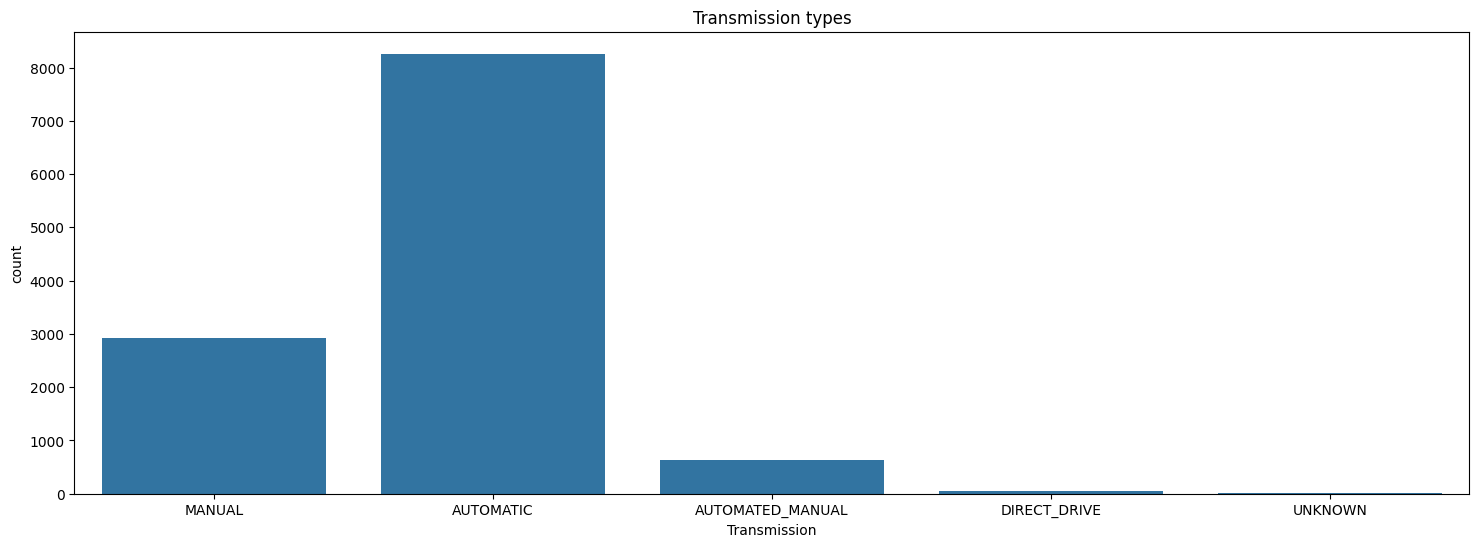

In [21]:
# Count the occurrences of each transmission type in dataset
plt.figure(figsize=(18, 6))
sns.countplot(x='Transmission', data=df)
plt.title('Transmission types')
plt.show()

In [22]:
df[df['Transmission'] == 'UNKNOWN'].shape

(19, 14)

In [23]:
# Remove rows where the Transmission type is unknown
df = df[df['Transmission'] != 'UNKNOWN']

In [24]:
df.shape

(11865, 14)

In [25]:
df['Fuel_Type'].unique()

array(['premium unleaded (required)', 'regular unleaded',
       'premium unleaded (recommended)', 'flex-fuel (unleaded/E85)',
       'diesel', 'electric',
       'flex-fuel (premium unleaded recommended/E85)', 'natural gas',
       'flex-fuel (premium unleaded required/E85)',
       'flex-fuel (unleaded/natural gas)'], dtype=object)

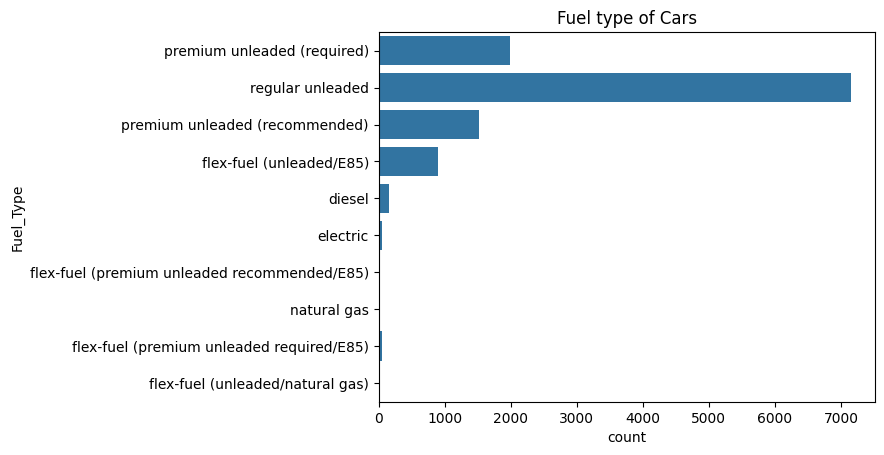

In [26]:
 # Count the occurrences of each fuel type in the dataset
sns.countplot(y='Fuel_Type', data=df)
plt.title('Fuel type of Cars')
plt.show()

In [27]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
regular unleaded,7153
premium unleaded (required),1992
premium unleaded (recommended),1523
flex-fuel (unleaded/E85),899
diesel,154
electric,56
flex-fuel (premium unleaded required/E85),54
flex-fuel (premium unleaded recommended/E85),26
flex-fuel (unleaded/natural gas),6


<Axes: ylabel='Frequency'>

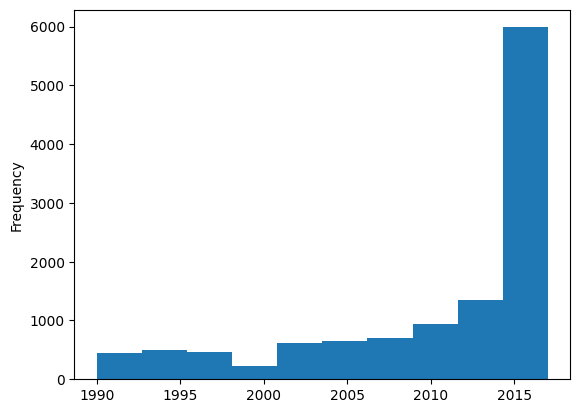

In [28]:
df['Year'].plot(kind='hist')

In [29]:
# Count the occurrences of each drive type in descending order
drive_type = df['Drive_Type'].value_counts(ascending=False).reset_index()
drive_type

,Drive_Type,count
0,front wheel drive,4776
1,rear wheel drive,3335
2,all wheel drive,2353
3,four wheel drive,1401


In [30]:
# Calculate the percentage distribution of transmission types across car brands
pd.crosstab(df['Transmission'],df['Brand'],normalize='columns')*100

Brand,Acura,Alfa Romeo,Aston Martin,Audi,BMW,Bentley,Bugatti,Buick,Cadillac,Chevrolet,...,Rolls-Royce,Saab,Scion,Spyker,Subaru,Suzuki,Tesla,Toyota,Volkswagen,Volvo
Transmission,,,,,,,,,,,,,,,,,,,,,
AUTOMATED_MANUAL,8.333333,100.0,23.655914,36.890244,5.389222,0.0,100.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.402685,27.329193,0.000000
AUTOMATIC,68.253968,0.0,40.860215,42.682927,76.347305,100.0,0.0,100.0,97.229219,66.458519,...,100.0,54.954955,55.0,0.0,62.890625,62.678063,0.0,82.684564,37.515528,85.053381
DIRECT_DRIVE,0.000000,0.0,0.000000,0.000000,1.197605,0.0,0.0,0.0,0.000000,0.713649,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,100.0,0.268456,0.000000,0.000000
MANUAL,23.412698,0.0,35.483871,20.426829,17.065868,0.0,0.0,0.0,2.770781,32.827832,...,0.0,45.045045,45.0,100.0,37.109375,37.321937,0.0,16.644295,35.155280,14.946619


In [31]:
# Calculate the percentage distribution of transmission types across car brands
pd.crosstab(df['Drive_Type'],df['Brand'],normalize='columns')*100

Brand,Acura,Alfa Romeo,Aston Martin,Audi,BMW,Bentley,Bugatti,Buick,Cadillac,Chevrolet,...,Rolls-Royce,Saab,Scion,Spyker,Subaru,Suzuki,Tesla,Toyota,Volkswagen,Volvo
Drive_Type,,,,,,,,,,,,,,,,,,,,,
all wheel drive,27.380952,0.0,0.0,77.439024,43.113772,64.864865,100.0,23.979592,30.730479,4.549509,...,0.0,30.630631,0.0,0.0,86.328125,15.384615,61.111111,9.798658,8.322981,35.587189
four wheel drive,1.587302,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,9.068010,23.104371,...,0.0,0.000000,0.0,0.0,3.515625,17.378917,0.000000,25.771812,0.248447,0.000000
front wheel drive,69.444444,0.0,0.0,22.560976,0.299401,0.000000,0.0,69.387755,16.876574,34.076717,...,0.0,69.369369,80.0,0.0,5.468750,50.427350,0.000000,42.281879,90.310559,45.907473
rear wheel drive,1.587302,100.0,100.0,0.000000,56.586826,35.135135,0.0,6.632653,43.324937,38.269402,...,100.0,0.000000,20.0,100.0,4.687500,16.809117,38.888889,22.147651,1.118012,18.505338


In [32]:
# Check the Top 10 Car Brands with the Highest Horsepower
top_hp = df.groupby('Brand')['Horsepower'].max().sort_values(ascending=False).reset_index().head(10)
top_hp

,Brand,Horsepower
0,Bugatti,1001.0
1,Lamborghini,750.0
2,Ferrari,731.0
3,Dodge,707.0
4,Ford,662.0
5,Chevrolet,650.0
6,McLaren,641.0
7,Mercedes-Benz,641.0
8,Cadillac,640.0
9,Maybach,631.0


<ipython-input-33-45f0b0735771>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.barplot(x='Brand', y = 'Horsepower', data=top_hp, palette = 'coolwarm')


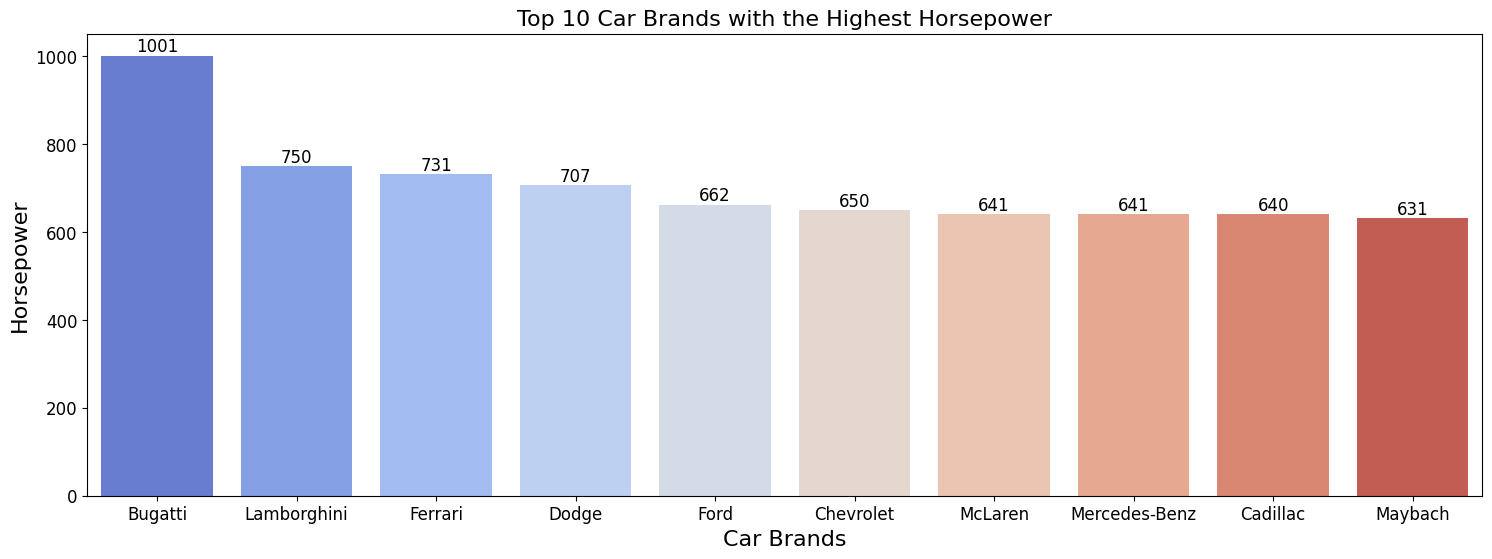

In [33]:
# Plot the Top 10 Car Brands with the Highest Horsepower
plt.figure(figsize=(18, 6))
fig = sns.barplot(x='Brand', y = 'Horsepower', data=top_hp, palette = 'coolwarm')
plt.title('Top 10 Car Brands with the Highest Horsepower', fontsize = 16)
plt.xlabel('Car Brands', fontsize = 16)
plt.ylabel('Horsepower', fontsize = 16)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

for i in fig.containers:
    fig.bar_label(i, fontsize = 12)


plt.show()

In [34]:
# Determine which fuel type of vehicles has the highest number of cylinders
fc = df.groupby(['Fuel_Type'])['Cylinders'].count().sort_values(ascending=False).reset_index()
fc

,Fuel_Type,Cylinders
0,regular unleaded,7153
1,premium unleaded (required),1992
2,premium unleaded (recommended),1523
3,flex-fuel (unleaded/E85),899
4,diesel,154
5,electric,56
6,flex-fuel (premium unleaded required/E85),54
7,flex-fuel (premium unleaded recommended/E85),26
8,flex-fuel (unleaded/natural gas),6
9,natural gas,2


<Axes: xlabel='Cylinders', ylabel='Fuel_Type'>

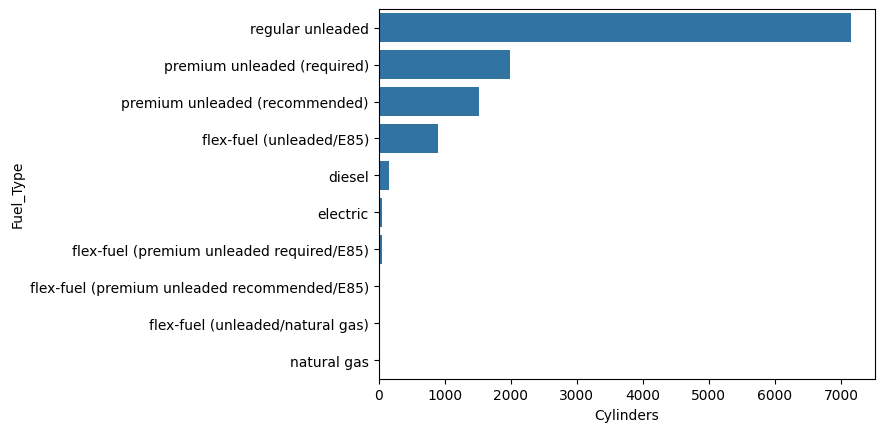

In [35]:
sns.barplot(y = 'Fuel_Type', x='Cylinders', data = fc)

In [36]:
# Get the top 10 brands by popularity  according to dataset
top_brands = df.groupby('Brand')['Popularity'].sum().reset_index().sort_values(by='Popularity', ascending=False).head(10)
top_brands

,Brand,Popularity
14,Ford,4983817
9,Chevrolet,1552585
45,Toyota,1513095
4,BMW,1307944
11,Dodge,1143918
33,Nissan,1121022
3,Audi,1018440
18,Honda,988698
46,Volkswagen,702765
8,Cadillac,644728


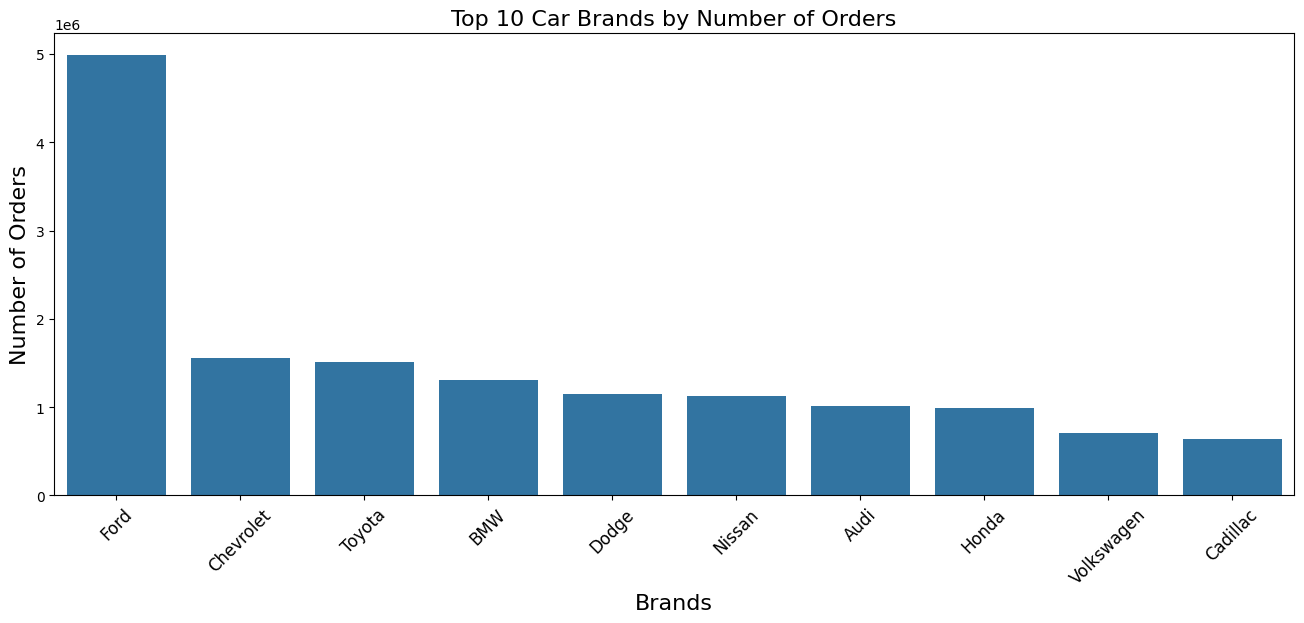

In [37]:
# top_brands.plot(kind='bar', x='Brand', y='Orders', legend=False)

# Plot the Top 10 Brands of Cars
plt.figure(figsize=(16, 6))
plt.xticks(rotation=45, fontsize=12)

fig = sns.barplot(data = top_brands, x='Brand', y= 'Popularity')
plt.xlabel('Brands', size=16)
plt.ylabel('Number of Orders', size=16)
plt.title('Top 10 Car Brands by Number of Orders', size=16)
plt.show()

In [38]:
# Check the top 10 Highest Price Cars
top_price = df.groupby('Brand')['Price'].mean().sort_values(ascending=False).reset_index().head(10)
top_price

,Brand,Price
0,Bugatti,1.757224e+06
1,Maybach,5.462219e+05
2,Rolls-Royce,3.511306e+05
3,Lamborghini,3.315673e+05
4,Bentley,2.471693e+05
5,McLaren,2.398050e+05
6,Ferrari,2.382188e+05
7,Spyker,2.133233e+05
8,Aston Martin,1.979104e+05
9,Maserati,1.142077e+05


In [39]:
pd.crosstab(df['Fuel_Type'],df['Brand'],normalize='columns')*100

Brand,Acura,Alfa Romeo,Aston Martin,Audi,BMW,Bentley,Bugatti,Buick,Cadillac,Chevrolet,...,Rolls-Royce,Saab,Scion,Spyker,Subaru,Suzuki,Tesla,Toyota,Volkswagen,Volvo
Fuel_Type,,,,,,,,,,,,,,,,,,,,,
diesel,0.000000,0.0,0.0,8.536585,5.988024,0.000000,0.0,0.000000,0.000000,0.089206,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,8.571429,0.000000
electric,0.000000,0.0,0.0,0.000000,1.197605,0.000000,0.0,0.000000,0.000000,0.535236,...,0.0,0.000000,0.0,0.0,0.000000,0.0,100.0,0.268456,0.000000,0.000000
flex-fuel (premium unleaded recommended/E85),0.000000,0.0,0.0,1.524390,0.000000,0.000000,0.0,0.000000,2.267003,0.000000,...,0.0,10.810811,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
flex-fuel (premium unleaded required/E85),0.000000,0.0,0.0,0.000000,0.000000,32.432432,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
flex-fuel (unleaded/E85),0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,18.877551,11.586902,22.390723,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,8.724832,0.869565,0.000000
flex-fuel (unleaded/natural gas),0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.535236,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
natural gas,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
premium unleaded (recommended),57.936508,0.0,0.0,28.658537,8.083832,0.000000,0.0,14.795918,27.959698,7.582516,...,0.0,44.144144,0.0,0.0,5.859375,0.0,0.0,0.268456,47.080745,13.879004
premium unleaded (required),17.063492,100.0,100.0,45.426829,81.736527,67.567568,100.0,1.530612,10.579345,2.854594,...,100.0,6.306306,20.0,100.0,33.203125,0.0,0.0,1.342282,3.602484,1.779359


In [40]:
# Check top 10 Year by popularity  according to dataset
top_brands = df.groupby(['Year', 'Brand'])['Popularity'].sum().reset_index().sort_values(by='Popularity', ascending=False).head(10)
top_brands

,Year,Brand,Popularity
714,2017,Ford,922091
681,2016,Ford,899463
645,2015,Ford,780666
636,2015,BMW,403348
702,2016,Toyota,387921
673,2016,BMW,364188
732,2017,Toyota,353394
666,2015,Toyota,347301
707,2017,BMW,309364
660,2015,Nissan,307377


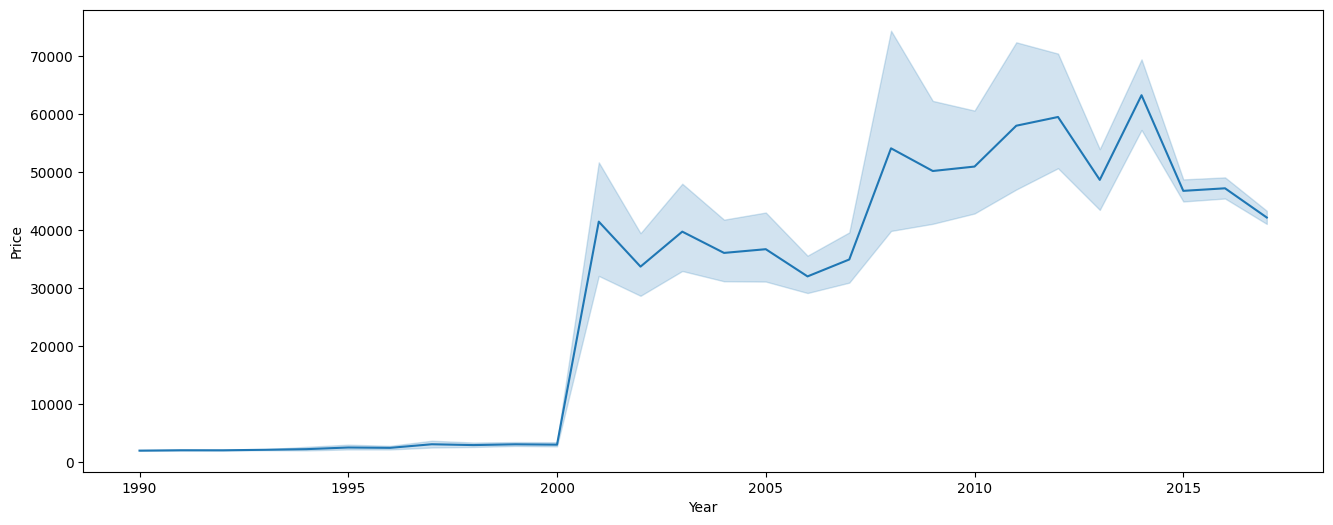

In [41]:
# Checking relationship of Year with Price

plt.figure(figsize=(16, 6))
sns.lineplot(x='Year',y='Price',data=df)
plt.show()

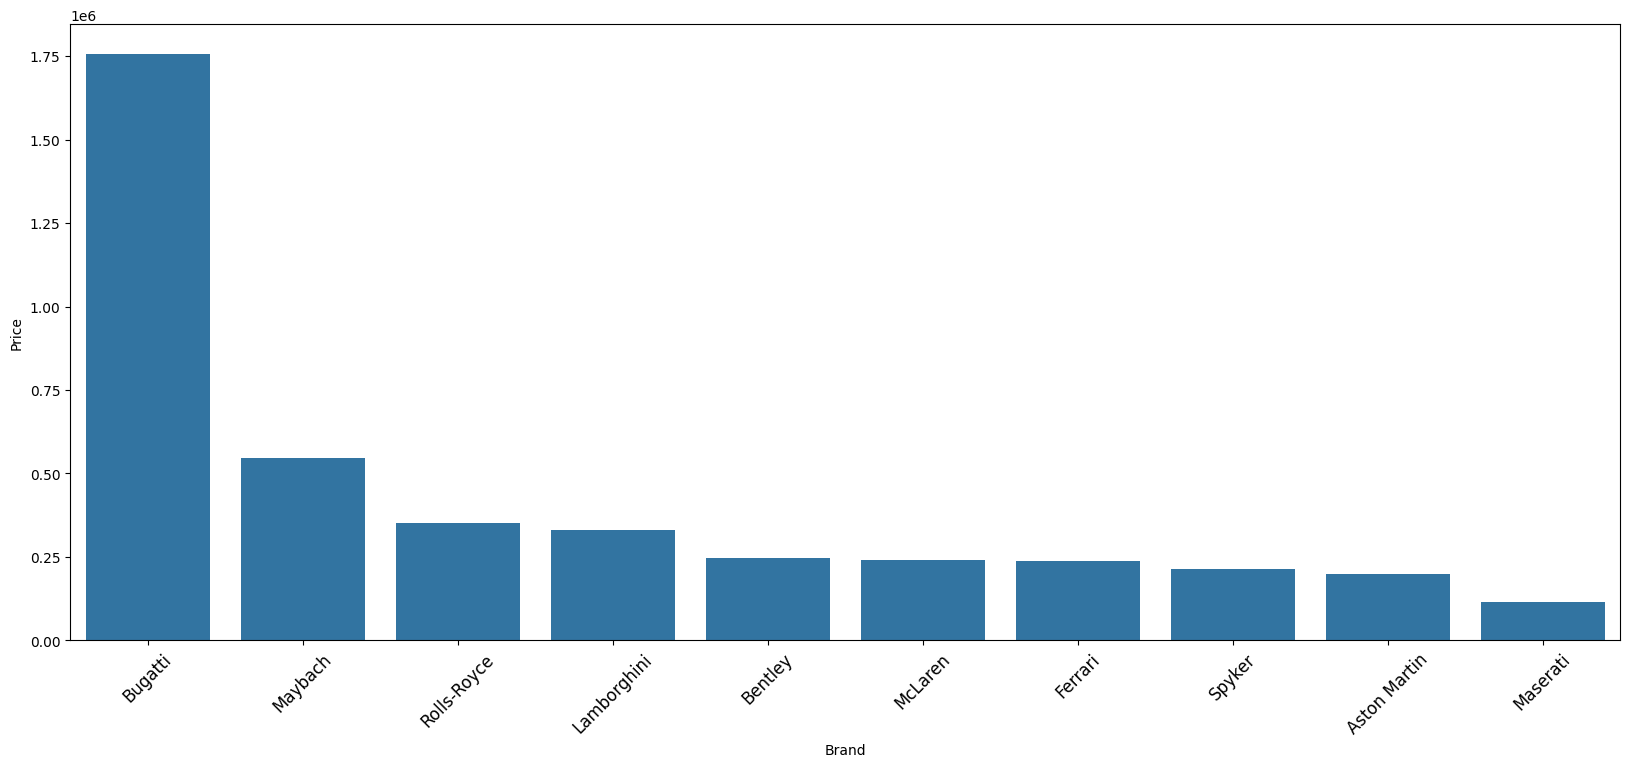

In [42]:
# Plot the top 10 cars with the highest prices
plt.figure(figsize=(20, 8))
plt.xticks(rotation=45, fontsize=12)
sns.barplot(x='Brand',y='Price',data=top_price)
plt.show()

In [43]:
# Create a cross-tabulation of Drive_Type vs Brand, showing percentage distribution for each brand.
pd.crosstab(df['Drive_Type'], df['Brand'], normalize = 'columns')*100

Brand,Acura,Alfa Romeo,Aston Martin,Audi,BMW,Bentley,Bugatti,Buick,Cadillac,Chevrolet,...,Rolls-Royce,Saab,Scion,Spyker,Subaru,Suzuki,Tesla,Toyota,Volkswagen,Volvo
Drive_Type,,,,,,,,,,,,,,,,,,,,,
all wheel drive,27.380952,0.0,0.0,77.439024,43.113772,64.864865,100.0,23.979592,30.730479,4.549509,...,0.0,30.630631,0.0,0.0,86.328125,15.384615,61.111111,9.798658,8.322981,35.587189
four wheel drive,1.587302,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,9.068010,23.104371,...,0.0,0.000000,0.0,0.0,3.515625,17.378917,0.000000,25.771812,0.248447,0.000000
front wheel drive,69.444444,0.0,0.0,22.560976,0.299401,0.000000,0.0,69.387755,16.876574,34.076717,...,0.0,69.369369,80.0,0.0,5.468750,50.427350,0.000000,42.281879,90.310559,45.907473
rear wheel drive,1.587302,100.0,100.0,0.000000,56.586826,35.135135,0.0,6.632653,43.324937,38.269402,...,100.0,0.000000,20.0,100.0,4.687500,16.809117,38.888889,22.147651,1.118012,18.505338


In [44]:
#Pivot table for 'Fuel_Type' vs 'Price'
df.pivot_table(values='Price', index='Fuel_Type', aggfunc='mean').sort_values(by='Price', ascending=False)


,Price
Fuel_Type,
flex-fuel (premium unleaded required/E85),159429.351852
premium unleaded (required),102240.693273
electric,50615.089286
flex-fuel (premium unleaded recommended/E85),48641.923077
premium unleaded (recommended),40812.831254
diesel,40788.000000
flex-fuel (unleaded/natural gas),39194.166667
flex-fuel (unleaded/E85),36258.260289
natural gas,28065.000000


In [45]:
# Pivot table for 'Drive_Type' vs 'Price'
pivot_drive_type_price = df.pivot_table(values='Price', index='Drive_Type', aggfunc='mean')
print(pivot_drive_type_price.sort_values(by='Price', ascending=False))

                          Price
Drive_Type                     
all wheel drive    58693.884828
rear wheel drive   55466.206897
four wheel drive   35358.955746
front wheel drive  23053.568049


In [46]:
# Pivot table for 'Vehicle_Size' vs 'Price'
df.pivot_table(values='Price', index='Vehicle_Size', aggfunc='mean').sort_values(by='Price', ascending=False)

,Price
Vehicle_Size,
Large,54040.418924
Midsize,39071.670254
Compact,34354.904842


In [47]:
# Pivot table for 'Vehicle_Style' vs 'Price'
df.pivot_table(values='Price', index='Vehicle_Style', aggfunc='mean').sort_values(by='Price', ascending=False)

,Price
Vehicle_Style,
Convertible,84422.618205
Coupe,77210.125315
4dr SUV,40418.100925
Sedan,39282.921562
Crew Cab Pickup,37220.466960
Passenger Van,29015.203125
Passenger Minivan,25621.050360
Wagon,25557.939189
Extended Cab Pickup,22488.776886


In [48]:
df.groupby(['Brand', 'Horsepower'])['Price'].mean().sort_values(ascending=False)

,,Price
Brand,Horsepower,
Bugatti,1001.0,1.757224e+06
Lamborghini,650.0,1.500000e+06
Maybach,620.0,7.545083e+05
Ferrari,660.0,6.433300e+05
Lamborghini,720.0,5.232250e+05
...,...,...
Oldsmobile,180.0,2.000000e+03
Ford,96.0,2.000000e+03
Oldsmobile,225.0,2.000000e+03


In [49]:
# Import library yang dibutuhkan
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Pisahkan dataset menjadi fitur (X) dan target (y)
X = df[['Horsepower', 'Cylinders', 'Highway_MPG']]  # Contoh fitur, sesuaikan dengan dataset
y = df['Price']

# Bagi dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model regresi linear biasa
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)  # Melatih model
y_pred_linear = linear_model.predict(X_test)  # Memprediksi data uji

# Model regresi linear dengan basis fungsi (contoh: polinomial derajat 2)
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)  # Mengubah fitur menjadi polinomial
X_test_poly = poly_features.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)  # Melatih model dengan fitur polinomial
y_pred_poly = poly_model.predict(X_test_poly)  # Memprediksi data uji dengan model polinomial

# Fungsi untuk menghitung metrik evaluasi
def print_metrics(y_true, y_pred, model_name):
    print(f"Metrics for {model_name}:")
    print(f"  Mean Squared Error (MSE): {mean_squared_error(y_true, y_pred)}")
    print(f"  Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_true, y_pred))}")
    print(f"  Mean Absolute Error (MAE): {mean_absolute_error(y_true, y_pred)}")
    print(f"  R-squared (R2): {r2_score(y_true, y_pred)}\n")

# Cetak metrik untuk model regresi linear biasa
print_metrics(y_test, y_pred_linear, "Linear Regression")

# Cetak metrik untuk model regresi linear dengan basis fungsi (polinomial)
print_metrics(y_test, y_pred_poly, "Polynomial Regression (Degree 2)")


Metrics for Linear Regression:
  Mean Squared Error (MSE): 1757558479.7705727
  Root Mean Squared Error (RMSE): 41923.24510066668
  Mean Absolute Error (MAE): 21668.43811507347
  R-squared (R2): 0.4909159207211202

Metrics for Polynomial Regression (Degree 2):
  Mean Squared Error (MSE): 1246336849.8355706
  Root Mean Squared Error (RMSE): 35303.49628345004
  Mean Absolute Error (MAE): 15926.192749526812
  R-squared (R2): 0.6389933791832032



In [50]:
# Import library tambahan untuk tabel perbandingan
import pandas as pd

# Simpan metrik evaluasi dari kedua model
results = {
    "Model": ["Linear Regression", "Polynomial Regression (Degree 2)"],
    "MSE": [
        mean_squared_error(y_test, y_pred_linear),
        mean_squared_error(y_test, y_pred_poly)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_pred_poly))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_poly)
    ],
    "R2": [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_poly)
    ]
}

# Buat DataFrame untuk perbandingan
results_df = pd.DataFrame(results)
print("Comparison of Model Performance Metrics:")
print(results_df)


Comparison of Model Performance Metrics:
                              Model           MSE          RMSE           MAE  \
0                 Linear Regression  1.757558e+09  41923.245101  21668.438115   
1  Polynomial Regression (Degree 2)  1.246337e+09  35303.496283  15926.192750   

         R2  
0  0.490916  
1  0.638993  


**Kesimpulan :**

1.   Jika model polinomial (basis fungsi) memberikan metrik yang lebih baik secara
signifikan (MSE, RMSE, MAE lebih rendah, dan R² lebih tinggi), ini menunjukkan bahwa model tersebut lebih baik dalam menangkap kompleksitas hubungan antara fitur dan target. Dalam kasus ini, regresi polinomial cocok untuk data dengan pola yang non-linear.
2.   Jika performa model linear lebih baik atau hampir sama, model linear mungkin sudah cukup untuk data ini. Regresi linear lebih sederhana dan tidak terlalu rentan terhadap overfitting dibandingkan dengan model polinomial.

